In [1]:
# ============================================================
# CHURN PREDICTION PROJECT
# XGBOOST — TEMPORAL OUT-OF-TIME TEST
# Core Behavior vs Extended Subscription Model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)



In [2]:
# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = "../data/churn_modeling_ready.csv"

MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../data")

MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)


In [3]:
# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["observation_date"]
)

print("Shape:", df.shape)

print(
    "Date range:",
    df["observation_date"].min(),
    "to",
    df["observation_date"].max()
)

print("\nTarget distribution:")
print(df["is_churn"].value_counts())

print("\nOverall churn rate:")
print(f"{df['is_churn'].mean():.2%}")



Shape: (32897, 32)
Date range: 2020-02-09 00:00:00 to 2020-05-10 00:00:00

Target distribution:
is_churn
0    32252
1      645
Name: count, dtype: int64

Overall churn rate:
1.96%


In [4]:
# ============================================================
# 3. TEMPORAL TRAIN / TEST SPLIT
# Must match Logistic Regression
# ============================================================

SPLIT_DATE = pd.Timestamp("2020-04-11")

train_df = df[
    df["observation_date"] < SPLIT_DATE
].copy()

test_df = df[
    df["observation_date"] >= SPLIT_DATE
].copy()


print("\nTRAIN")
print("Rows:", len(train_df))
print(
    "Dates:",
    train_df["observation_date"].min(),
    "to",
    train_df["observation_date"].max()
)
print("Churns:", train_df["is_churn"].sum())
print(
    "Churn rate:",
    f"{train_df['is_churn'].mean():.2%}"
)


print("\nTEST")
print("Rows:", len(test_df))
print(
    "Dates:",
    test_df["observation_date"].min(),
    "to",
    test_df["observation_date"].max()
)
print("Churns:", test_df["is_churn"].sum())
print(
    "Churn rate:",
    f"{test_df['is_churn'].mean():.2%}"
)


y_train = train_df["is_churn"].astype(int)
y_test = test_df["is_churn"].astype(int)



TRAIN
Rows: 21252
Dates: 2020-02-09 00:00:00 to 2020-04-10 00:00:00
Churns: 457
Churn rate: 2.15%

TEST
Rows: 11645
Dates: 2020-04-11 00:00:00 to 2020-05-10 00:00:00
Churns: 188
Churn rate: 1.61%


In [5]:
# ============================================================
# 4. FEATURE SETS
# ============================================================

# ------------------------------------------------------------
# CORE MODEL
# Customer + behavioral information
# ------------------------------------------------------------

core_categorical = [
    "channel",
    "country"
]


core_numeric = [
    "customer_age",
    "account_tenure_days",

    # Raw behavior
    "post_per_month",
    "newfriend_per_month",
    "like_per_month",
    "adview_per_month",
    "dislike_per_month",
    "unfriend_per_month",
    "message_per_month",
    "reply_per_month",

    # Engineered behavior
    "total_engagement",
    "negative_engagement",
    "total_activity",
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "negative_activity_share",
    "adview_share"
]


core_features = (
    core_categorical
    + core_numeric
)


In [6]:
# ------------------------------------------------------------
# EXTENDED MODEL
# Adds subscription economics and plan movement
# ------------------------------------------------------------

extended_categorical = [
    "channel",
    "country",
    "current_plan"
]


extended_numeric = core_numeric + [

    "current_mrr",
    "bill_period_months",
    "discount",

    "mrr_change",

    "upgrade_flag",
    "downsell_flag",

    "upgrade_last_90d",
    "downsell_last_90d"
]


extended_features = (
    extended_categorical
    + extended_numeric
)


print("\nCore features:", len(core_features))
print("Extended features:", len(extended_features))


Core features: 20
Extended features: 29


In [7]:
# ============================================================
# 5. PREPROCESSING FUNCTION
# ============================================================

def make_preprocessor(categorical, numeric):

    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical
            ),
            (
                "numeric",
                "passthrough",
                numeric
            )
        ]
    )

In [8]:
# ============================================================
# 6. PREPARE CORE MODEL DATA
# ============================================================

core_preprocessor = make_preprocessor(
    core_categorical,
    core_numeric
)

X_train_core = core_preprocessor.fit_transform(
    train_df[core_features]
)

X_test_core = core_preprocessor.transform(
    test_df[core_features]
)


print("\nCore transformed shape:")
print(
    X_train_core.shape,
    X_test_core.shape
)



Core transformed shape:
(21252, 48) (11645, 48)


In [9]:
# ============================================================
# 7. PREPARE EXTENDED MODEL DATA
# ============================================================

extended_preprocessor = make_preprocessor(
    extended_categorical,
    extended_numeric
)

X_train_extended = (
    extended_preprocessor.fit_transform(
        train_df[extended_features]
    )
)

X_test_extended = (
    extended_preprocessor.transform(
        test_df[extended_features]
    )
)


print("\nExtended transformed shape:")
print(
    X_train_extended.shape,
    X_test_extended.shape
)




Extended transformed shape:
(21252, 59) (11645, 59)


In [10]:
# ============================================================
# 8. XGBOOST PARAMETERS
# ============================================================

xgb_params = {

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "n_estimators": 400,

    "learning_rate": 0.03,

    "max_depth": 4,

    "min_child_weight": 5,

    "subsample": 0.8,

    "colsample_bytree": 0.8,

    "reg_alpha": 0.1,

    "reg_lambda": 1.0,

    "tree_method": "hist",

    "random_state": 42,

    "n_jobs": -1
}



In [11]:
# ============================================================
# 9. CORE XGBOOST MODEL
# ============================================================

core_xgb = XGBClassifier(
    **xgb_params
)

core_xgb.fit(
    X_train_core,
    y_train
)


core_probability = core_xgb.predict_proba(
    X_test_core
)[:, 1]



In [12]:
# ============================================================
# 10. EXTENDED XGBOOST MODEL
# ============================================================

extended_xgb = XGBClassifier(
    **xgb_params
)

extended_xgb.fit(
    X_train_extended,
    y_train
)


extended_probability = (
    extended_xgb.predict_proba(
        X_test_extended
    )[:, 1]
)



In [13]:
# ============================================================
# 11. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    name,
    y_true,
    probabilities
):

    roc_auc = roc_auc_score(
        y_true,
        probabilities
    )

    pr_auc = average_precision_score(
        y_true,
        probabilities
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        f"ROC-AUC: {roc_auc:.4f}"
    )

    print(
        f"PR-AUC:  {pr_auc:.4f}"
    )

    print(
        f"Random PR baseline: "
        f"{y_true.mean():.4f}"
    )

    return {
        "model": name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


In [14]:
# ============================================================
# 12. EVALUATE BOTH MODELS
# ============================================================

core_results = evaluate_model(
    "Core Behavior XGBoost",
    y_test,
    core_probability
)


extended_results = evaluate_model(
    "Extended Subscription XGBoost",
    y_test,
    extended_probability
)


comparison = pd.DataFrame(
    [
        core_results,
        extended_results
    ]
)

print("\nXGBOOST MODEL COMPARISON")

display(comparison)


Core Behavior XGBoost
ROC-AUC: 0.6619
PR-AUC:  0.0589
Random PR baseline: 0.0161

Extended Subscription XGBoost
ROC-AUC: 0.6735
PR-AUC:  0.0620
Random PR baseline: 0.0161

XGBOOST MODEL COMPARISON


,model,roc_auc,pr_auc
0,Core Behavior XGBoost,0.661918,0.058901
1,Extended Subscription XGBoost,0.673504,0.062002


In [15]:

# ============================================================
# 13. COMPARE WITH LOGISTIC REGRESSION
# ============================================================

all_models = pd.DataFrame({

    "model": [
        "Logistic - Core",
        "Logistic - Extended",
        "XGBoost - Core",
        "XGBoost - Extended"
    ],

    "roc_auc": [
        0.6529,
        0.6526,
        core_results["roc_auc"],
        extended_results["roc_auc"]
    ],

    "pr_auc": [
        0.0426,
        0.0438,
        core_results["pr_auc"],
        extended_results["pr_auc"]
    ]
})


print("\nALL MODEL COMPARISON")

display(
    all_models.sort_values(
        "pr_auc",
        ascending=False
    )
)




ALL MODEL COMPARISON


,model,roc_auc,pr_auc
3,XGBoost - Extended,0.673504,0.062002
2,XGBoost - Core,0.661918,0.058901
1,Logistic - Extended,0.652600,0.043800
0,Logistic - Core,0.652900,0.042600


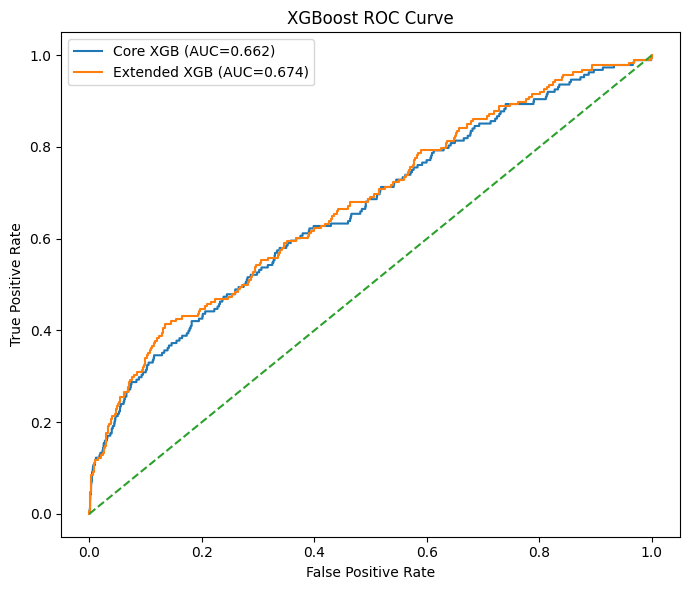

In [16]:
# ============================================================
# 14. ROC CURVES
# ============================================================

core_fpr, core_tpr, _ = roc_curve(
    y_test,
    core_probability
)

ext_fpr, ext_tpr, _ = roc_curve(
    y_test,
    extended_probability
)


plt.figure(figsize=(7, 6))

plt.plot(
    core_fpr,
    core_tpr,
    label=(
        f"Core XGB "
        f"(AUC={core_results['roc_auc']:.3f})"
    )
)

plt.plot(
    ext_fpr,
    ext_tpr,
    label=(
        f"Extended XGB "
        f"(AUC={extended_results['roc_auc']:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "XGBoost ROC Curve"
)

plt.legend()

plt.tight_layout()

plt.show()



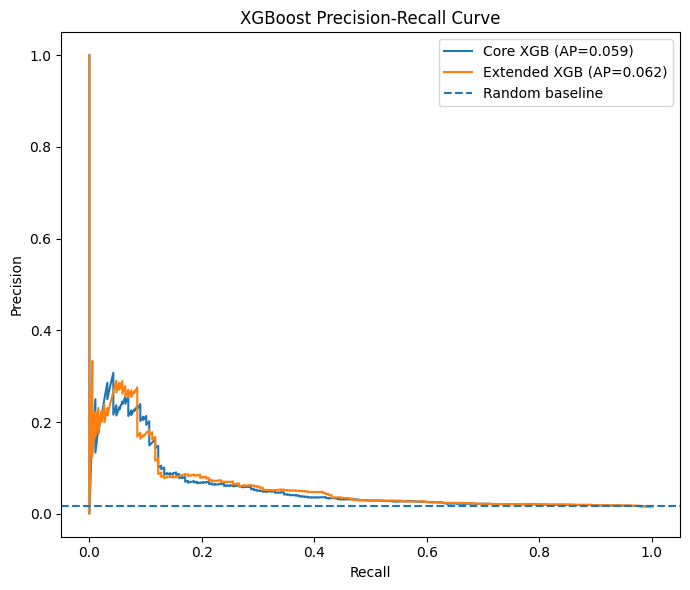

In [17]:
# ============================================================
# 15. PRECISION-RECALL CURVES
# ============================================================

core_precision, core_recall, _ = (
    precision_recall_curve(
        y_test,
        core_probability
    )
)

ext_precision, ext_recall, _ = (
    precision_recall_curve(
        y_test,
        extended_probability
    )
)


plt.figure(figsize=(7, 6))

plt.plot(
    core_recall,
    core_precision,
    label=(
        f"Core XGB "
        f"(AP={core_results['pr_auc']:.3f})"
    )
)

plt.plot(
    ext_recall,
    ext_precision,
    label=(
        f"Extended XGB "
        f"(AP={extended_results['pr_auc']:.3f})"
    )
)

plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "XGBoost Precision-Recall Curve"
)

plt.legend()

plt.tight_layout()

plt.show()



In [18]:
# ============================================================
# 16. TOP-K / LIFT ANALYSIS
# ============================================================

def top_k_metrics(
    y_true,
    probabilities,
    percentages=(
        0.05,
        0.10,
        0.20
    )
):

    result = pd.DataFrame({

        "actual":
            np.asarray(y_true),

        "probability":
            probabilities
    })


    result = result.sort_values(
        "probability",
        ascending=False
    )


    overall_rate = (
        result["actual"].mean()
    )

    total_churns = (
        result["actual"].sum()
    )


    rows = []


    for pct in percentages:

        n = max(
            1,
            int(len(result) * pct)
        )

        top = result.head(n)

        top_churns = (
            top["actual"].sum()
        )

        precision = (
            top["actual"].mean()
        )

        recall = (
            top_churns
            / total_churns
        )

        lift = (
            precision
            / overall_rate
        )


        rows.append({

            "top_population_pct":
                pct * 100,

            "customers_targeted":
                n,

            "churners_found":
                int(top_churns),

            "precision":
                precision,

            "recall_of_all_churners":
                recall,

            "lift":
                lift
        })


    return pd.DataFrame(rows)



In [19]:
# ============================================================
# 17. CORE TOP-K
# ============================================================

print("\nCORE XGBOOST — TOP-K")

core_lift = top_k_metrics(
    y_test,
    core_probability
)

display(core_lift)



CORE XGBOOST — TOP-K


,top_population_pct,customers_targeted,churners_found,precision,recall_of_all_churners,lift
0,5.0,582,40,0.068729,0.212766,4.257147
1,10.0,1164,58,0.049828,0.308511,3.086432
2,20.0,2329,80,0.034350,0.425532,2.127660


In [20]:
# ============================================================
# 18. EXTENDED TOP-K
# ============================================================

print("\nEXTENDED XGBOOST — TOP-K")

extended_lift = top_k_metrics(
    y_test,
    extended_probability
)

display(extended_lift)




EXTENDED XGBOOST — TOP-K


,top_population_pct,customers_targeted,churners_found,precision,recall_of_all_churners,lift
0,5.0,582,42,0.072165,0.223404,4.470004
1,10.0,1164,60,0.051546,0.319149,3.192860
2,20.0,2329,83,0.035638,0.441489,2.207447


In [21]:
# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    extended_preprocessor
    .get_feature_names_out()
)


importance_df = pd.DataFrame({

    "feature":
        feature_names,

    "importance":
        extended_xgb.feature_importances_
})


importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
)


print("\nTOP XGBOOST FEATURES")

display(
    importance_df.head(25)
)


TOP XGBOOST FEATURES


,feature,importance
43,numeric__total_engagement,0.057246
42,numeric__reply_per_month,0.037523
34,numeric__account_tenure_days,0.035640
36,numeric__newfriend_per_month,0.032505
41,numeric__message_per_month,0.031875
47,numeric__unfriend_rate,0.031689
35,numeric__post_per_month,0.030159
45,numeric__total_activity,0.027056
6,categorical__country_CA,0.026445
1,categorical__channel_appstore2,0.025410


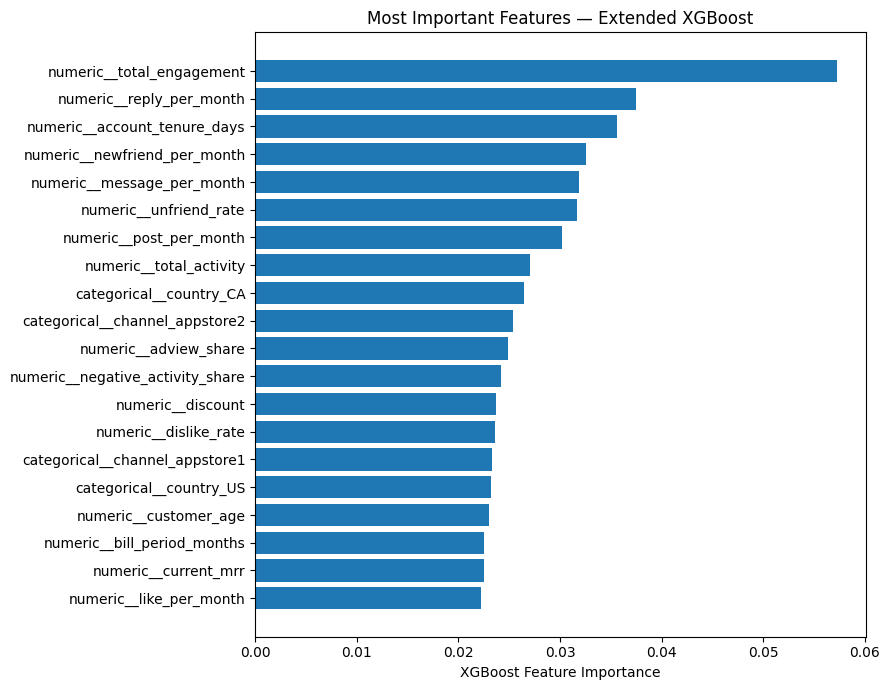

In [22]:
# ============================================================
# 20. FEATURE IMPORTANCE PLOT
# ============================================================

top_importance = (
    importance_df
    .head(20)
    .sort_values("importance")
)


plt.figure(figsize=(9, 7))

plt.barh(
    top_importance["feature"],
    top_importance["importance"]
)

plt.xlabel(
    "XGBoost Feature Importance"
)

plt.title(
    "Most Important Features — Extended XGBoost"
)

plt.tight_layout()

plt.show()



In [23]:
# ============================================================
# 21. CREATE TEST PREDICTIONS
# ============================================================

predictions = test_df[
    [
        "account_id",
        "observation_date",
        "is_churn",
        "current_plan",
        "current_mrr",
        "upgrade_last_90d",
        "downsell_last_90d"
    ]
].copy()


predictions[
    "xgb_churn_probability"
] = extended_probability


predictions[
    "risk_rank"
] = (
    predictions[
        "xgb_churn_probability"
    ]
    .rank(
        method="first",
        ascending=False
    )
)


predictions[
    "monthly_revenue_at_risk"
] = (
    predictions[
        "xgb_churn_probability"
    ]
    *
    predictions[
        "current_mrr"
    ]
)


predictions = (
    predictions
    .sort_values(
        "xgb_churn_probability",
        ascending=False
    )
)


display(
    predictions.head(20)
)

,account_id,observation_date,is_churn,current_plan,current_mrr,upgrade_last_90d,downsell_last_90d,xgb_churn_probability,risk_rank,monthly_revenue_at_risk
5500,1967,2020-04-13,0,plus,19.0,0,0,0.491160,1.0,9.332045
31081,11348,2020-04-27,0,basic,10.0,0,0,0.476819,2.0,4.768186
32112,12030,2020-05-01,1,basic,10.0,0,0,0.460800,3.0,4.608003
10450,3709,2020-04-11,0,premium,35.0,0,0,0.454001,4.0,15.890023
2798,995,2020-05-01,0,basic,9.0,0,0,0.390919,5.0,3.518268
30136,10836,2020-04-15,0,plus,20.0,0,0,0.377166,6.0,7.543323
27734,9874,2020-04-12,0,basic,9.5,0,0,0.376742,7.0,3.579053
4571,1635,2020-05-05,0,basic,10.0,0,0,0.360098,8.0,3.600976
32670,12925,2020-04-26,1,basic,10.0,0,0,0.358423,9.0,3.584225
7172,2566,2020-04-17,0,plus,19.0,0,0,0.357454,10.0,6.791617


In [24]:
# ============================================================
# 22. SAVE PREPROCESSOR + MODEL
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "xgboost_extended.pkl"
)


joblib.dump(
    {
        "preprocessor":
            extended_preprocessor,

        "model":
            extended_xgb,

        "features":
            extended_features
    },
    MODEL_PATH
)


print(
    "\nSaved model:",
    MODEL_PATH
)


Saved model: ../models/xgboost_extended.pkl


In [25]:

# ============================================================
# 23. SAVE PREDICTIONS
# ============================================================

PRED_PATH = (
    OUTPUT_DIR
    / "xgboost_test_predictions.csv"
)


predictions.to_csv(
    PRED_PATH,
    index=False
)


print(
    "Saved predictions:",
    PRED_PATH
)



Saved predictions: ../data/xgboost_test_predictions.csv


In [26]:
# ============================================================
# 24. SAVE MODEL COMPARISON
# ============================================================

all_models.to_csv(
    OUTPUT_DIR
    / "final_model_comparison.csv",
    index=False
)

In [27]:
# ============================================================
# 25. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)

print(
    "XGBOOST MODELING COMPLETE"
)

print("=" * 60)


print(
    "\nCore XGBoost ROC-AUC:",
    round(
        core_results["roc_auc"],
        4
    )
)

print(
    "Core XGBoost PR-AUC:",
    round(
        core_results["pr_auc"],
        4
    )
)


print(
    "\nExtended XGBoost ROC-AUC:",
    round(
        extended_results["roc_auc"],
        4
    )
)

print(
    "Extended XGBoost PR-AUC:",
    round(
        extended_results["pr_auc"],
        4
    )
)


print(
    "\nTest churn baseline:",
    round(
        y_test.mean(),
        4
    )
)


XGBOOST MODELING COMPLETE

Core XGBoost ROC-AUC: 0.6619
Core XGBoost PR-AUC: 0.0589

Extended XGBoost ROC-AUC: 0.6735
Extended XGBoost PR-AUC: 0.062

Test churn baseline: 0.0161
